In [1]:
""""

1 - Print Number Record and Number Features 

2 - Display information 

3 - Display Description

4 - Print mean of Age

5 - Histogram For Age     

6 - Value Counts for Sex

7 - Bar Chart for Gender Distribution 

8 - Bar Chart for Heart Disease in Patients with High Blood Pressure (> 170)

9 - Histogram for Cholesterol

10 - Splitting the Data

11 - Scaling the Features 

12 - Training the SVM Model

13 - Display accuracy score ( > 70 % ) 
"""

'"\n\n1 - Print Number Record and Number Features \n\n2 - Display information \n\n3 - Display Description\n\n4 - Print mean of Age\n\n5 - Histogram For Age     \n\n6 - Value Counts for Sex\n\n7 - Bar Chart for Gender Distribution \n\n8 - Bar Chart for Heart Disease in Patients with High Blood Pressure (> 170)\n\n9 - Histogram for Cholesterol\n\n10 - Splitting the Data\n\n11 - Scaling the Features \n\n12 - Training the SVM Model\n\n13 - Display accuracy score ( > 70 % ) \n'

In [2]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [3]:
#1 - Print Number Record and Number Features 
#2 - Display information 
#3 - Display Description

df = pd.read_csv('heart.csv')
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
#4 - print mean of Age
print("Mean of Age:", df['Age'].mean())

Mean of Age: 53.510893246187365


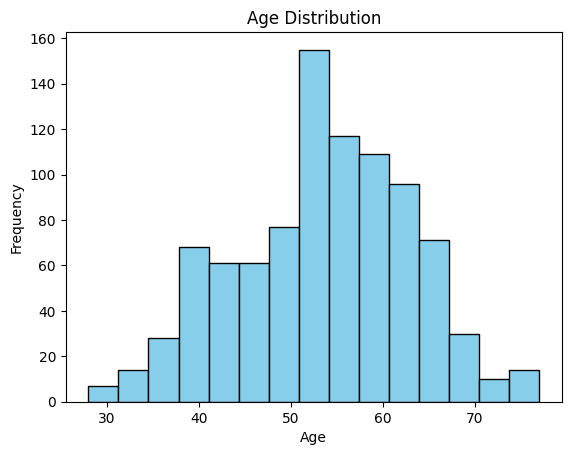

In [5]:
#5 - Histogram For Age     
plt.hist(df['Age'], bins=15, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [6]:
#6 - Value Counts for Sex
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

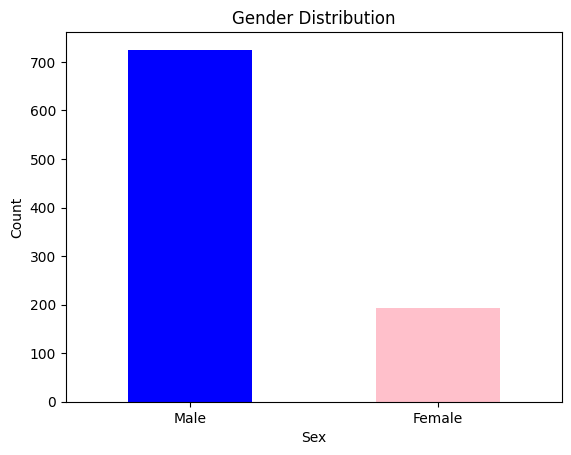

In [7]:
#7 - Bar Chart for Gender Distribution 
gender_counts = df['Sex'].value_counts()
gender_counts.plot(kind='bar', color=['blue', 'pink'])
plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels=['Male', 'Female'], rotation=0)
plt.show()

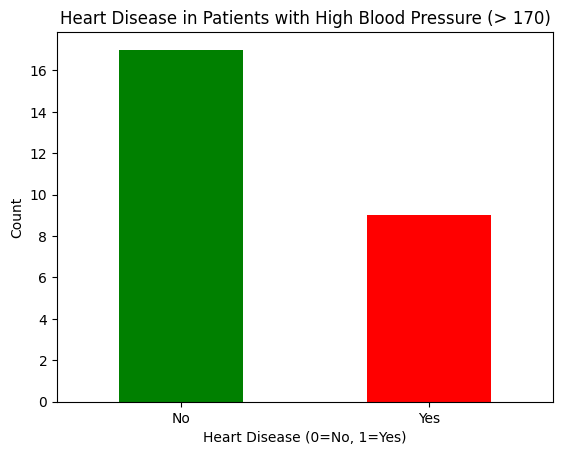

In [8]:
#8 - Bar Chart for Heart Disease in Patients with High Blood Pressure (> 170)
high_bp = df[df['RestingBP'] > 170]
heart_disease_counts = high_bp['HeartDisease'].value_counts()
heart_disease_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Heart Disease in Patients with High Blood Pressure (> 170)')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels=['No', 'Yes'], rotation=0)
plt.show()

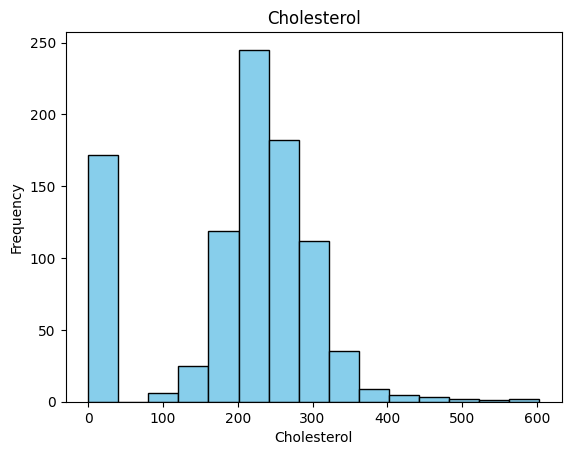

In [9]:
#9 - Histogram for Cholesterol
plt.hist(df['Cholesterol'], bins=15, color='skyblue', edgecolor='black')
plt.title('Cholesterol')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.show()

In [10]:
#10 - Splitting the Data
x = df[['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',  'Oldpeak', ]]

y = df['HeartDisease']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)


In [11]:
#11 - Scaling the Features 
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [12]:
#12 - Training the SVM Model
model = SVC()
model.fit(x_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [13]:
#13 - Display accuracy score ( > 70 % )
y_pred = model.predict(x_test)
y_pred


array([1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1])

In [14]:
y_test

306    1
711    0
298    1
466    1
253    0
      ..
909    1
293    1
761    1
2      0
409    1
Name: HeartDisease, Length: 184, dtype: int64

In [15]:
print(accuracy_score(y_test, y_pred) * 100,'%')

78.26086956521739 %


In [16]:
df[['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']]

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1
914,68,144,193,1,141,3.4,1
915,57,130,131,0,115,1.2,1
916,57,130,236,0,174,0.0,1


In [17]:
#predict
#Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',  'Oldpeak
age = float(input("Enter Age: "))
resting_bp = float(input("Enter RestingBP: "))
cholesterol = float(input("Enter Cholesterol: "))
fasting_bs = float(input("Enter FastingBS (0 or 1): "))
max_hr = float(input("Enter MaxHR: "))
oldpeak = float(input("Enter Oldpeak: "))

# Combine inputs into a list
custom_data = [[age, resting_bp, cholesterol, fasting_bs, max_hr, oldpeak]]

# Scale the custom data using the same scaler
custom_data_scaled = scaler.transform(custom_data)

# Predict
prediction = model.predict(custom_data_scaled)
print("Prediction (0=No Heart Disease, 1=Heart Disease):", prediction[0])
if prediction[0] == 1:
    print("The patient is likely to have heart disease.")
else:
    print("The patient is unlikely to have heart disease.")

Prediction (0=No Heart Disease, 1=Heart Disease): 1
The patient is likely to have heart disease.


c:\Users\youss\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
